# 17 millones de parches de bosque. Los grandes capturan más carbono por hectárea que los pequeños.

Una hectárea metida dentro de un bosque continuo de ~100 000 km² es, en promedio, **38 % más productiva** que esa misma hectárea aislada en un parche pequeño.

Eso lo dice un paper publicado en *Nature Ecology & Evolution* en 2026 que mapeó toda la productividad forestal de Estados Unidos continental y la comparó por tamaño de parche. Y luego repitió el ejercicio en seis continentes.

| | |
|---|---|
| **Paper** | Larger forest patches have greater per-area productivity |
| **DOI** | [10.1038/s41559-026-03075-5](https://doi.org/10.1038/s41559-026-03075-5) |
| **Datos** | [Zenodo · v3.0.0](https://doi.org/10.5281/zenodo.19134763) |
| **Video corto** | [Pendiente] |
| **Reproducir** | [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-15-parches-bosque-productividad/notebook.ipynb) |

> **Diseño del estudio:** observacional (sensores remotos + modelos espaciales). Los datos *muestran asociación* entre tamaño de parche y productividad — no son un experimento controlado.

## Qué midieron

El equipo dividió Estados Unidos continental en **16,9 millones** de parches forestales (cualquier mancha de bosque rodeada de no-bosque). Para cada parche calcularon la **productividad primaria neta** (NPP) — cuánto carbono fijan los árboles por metro cuadrado al año, medida con sensores remotos.

Para descontar el efecto del clima, suelo y topografía (un parche grande en Florida no es comparable a uno pequeño en Wyoming), corren un modelo que estima la **NPP parcial**: lo que queda atribuible al *tamaño del parche* después de controlar por todo lo demás.

Después extendieron el análisis a seis continentes con resolución más gruesa, para ver si la relación se sostiene fuera de Norteamérica.

Veamos qué encontraron.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS = '#2563EB'        # Azul CaM — datos principales
COLOR_ALERTA = '#DC2626'       # Rojo — referencia / contraste
COLOR_REFERENCIA = '#D97706'   # Amber — escenario de referencia
COLOR_SECUNDARIO = '#059669'   # Emerald — escenario alternativo
COLOR_GRIS = '#999999'
FUENTE = 'Fuente: Zou et al. (2026), Nature Ecol. Evol. | Datos: Zenodo 19134763'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Estilo CaM (local → fallback raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar los 4 datasets
df_size = pd.read_csv('datos/npp_por_tamano.csv')
df_scen = pd.read_csv('datos/escenarios_npp.csv')
df_imp  = pd.read_csv('datos/importancia_variables.csv')
df_cont = pd.read_csv('datos/pendientes_por_continente.csv')

print(f'Parches por clase de tamaño:  {len(df_size)} bins, {df_size["n_parches"].sum():,} parches')
print(f'Escenarios contrafactuales:   {len(df_scen)}')
print(f'Variables del Random Forest:  {len(df_imp)}')
print(f'Continentes analizados:       {len(df_cont)}')

Parches por clase de tamaño:  9 bins, 16,913,643 parches
Escenarios contrafactuales:   3
Variables del Random Forest:  7
Continentes analizados:       6


## Aquí está.

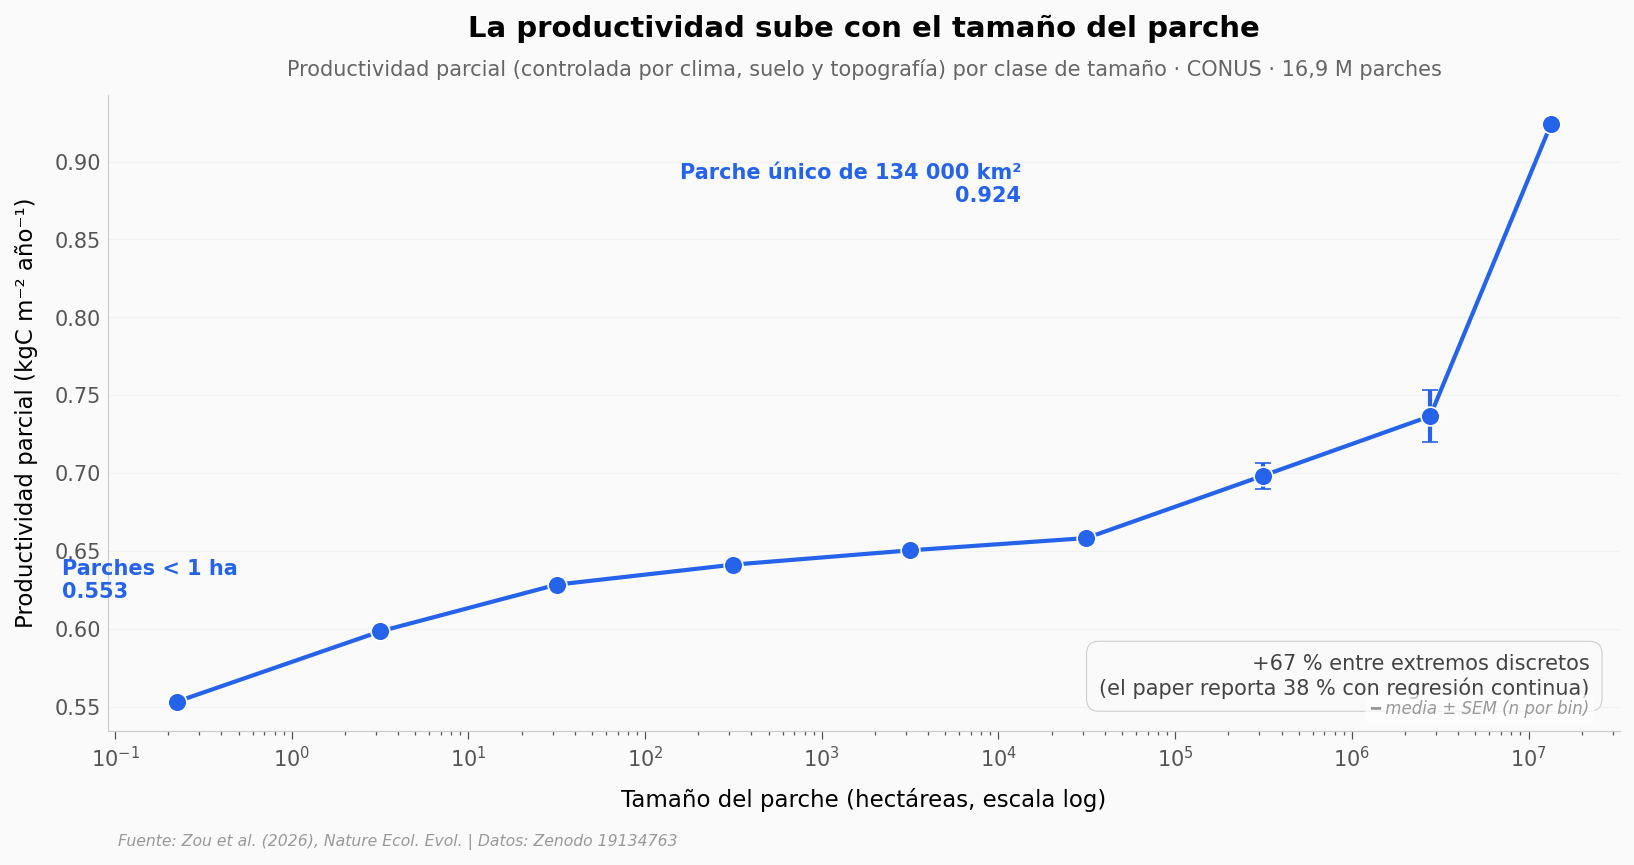

In [2]:
# Centros de bin en escala log para la curva
df_size = df_size.copy()
df_size['size_mid_m2'] = np.sqrt(df_size['min_size_m2'] * df_size['max_size_m2'])
df_size['size_mid_ha'] = df_size['size_mid_m2'] / 1e4

fig, ax = plt.subplots(figsize=(13, 5.5))

# Línea + puntos con error bar (sd / sqrt(n))
sd  = df_size['npp_parcial_sd'].fillna(0)
n   = df_size['n_parches']
sem = sd / np.sqrt(n)

ax.errorbar(
    df_size['size_mid_ha'],
    df_size['npp_parcial'],
    yerr=sem,
    fmt='o-',
    color=COLOR_DATOS,
    markersize=9,
    linewidth=2,
    markeredgecolor='white',
    markeredgewidth=0.8,
    capsize=4,
    capthick=1.2,
    zorder=5,
)

ax.set_xscale('log')
ax.set_xlabel('Tamaño del parche (hectáreas, escala log)', fontsize=11)
ax.set_ylabel('Productividad parcial (kgC m⁻² año⁻¹)', fontsize=11)

# Etiqueta del primer y último bin con el valor concreto
ax.annotate(
    f'Parches < 1 ha\n{df_size.iloc[0]["npp_parcial"]:.3f}',
    xy=(df_size.iloc[0]['size_mid_ha'], df_size.iloc[0]['npp_parcial']),
    xytext=(0.05, 0.62),
    fontsize=10, color=COLOR_DATOS, fontweight='bold',
)
ax.annotate(
    f'Parche único de 134 000 km²\n{df_size.iloc[-1]["npp_parcial"]:.3f}',
    xy=(df_size.iloc[-1]['size_mid_ha'], df_size.iloc[-1]['npp_parcial']),
    xytext=(df_size.iloc[-1]['size_mid_ha'] / 1000, df_size.iloc[-1]['npp_parcial'] - 0.05),
    fontsize=10, color=COLOR_DATOS, fontweight='bold',
    ha='right',
)

# Diferencia entre extremos como cifra principal
diff_pct = (df_size.iloc[-1]['npp_parcial'] - df_size.iloc[0]['npp_parcial']) / df_size.iloc[0]['npp_parcial'] * 100
ax.text(
    0.98, 0.05,
    f'+{diff_pct:.0f} % entre extremos discretos\n(el paper reporta 38 % con regresión continua)',
    transform=ax.transAxes, fontsize=10, color='#444444',
    ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#FAFAFA', edgecolor='#CCCCCC'),
)

ax.set_title('La productividad sube con el tamaño del parche',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Productividad parcial (controlada por clima, suelo y topografía) por clase de tamaño · CONUS · 16,9 M parches',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.grid(True, alpha=0.3, axis='y')
ax.text(0.98, 0.02, '━ media ± SEM (n por bin)', transform=ax.transAxes,
        fontsize=8, color=COLOR_GRIS, ha='right', va='bottom', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color=COLOR_GRIS, style='italic')
plt.savefig('figuras/01_npp_vs_tamano.png', dpi=200, bbox_inches='tight')
plt.show()

La curva sube de forma monótona. Los parches más pequeños (menos de una hectárea) fijan en promedio **0,55 kgC por m² al año**; el parche único más grande del país (134 000 km², básicamente el bosque continuo de la cordillera del Pacífico) llega a **0,92 kgC por m² al año** (NPP parcial, controlada por clima/suelo/topografía).

El salto entre extremos discretos es de **+67 %** — pero ese último bin tiene n=1 (un solo parche), por eso preferimos la regresión continua del paper. El paper reporta **+38 %** porque ajusta una regresión continua sobre todo el rango (más estable, menos sensible a un solo bin con n = 1).

Lo importante: *después de descontar* clima, suelo y topografía. La diferencia es atribuible al tamaño del parche en sí — más interior, menos efecto de borde, microclima más estable.

## ¿Cuánto carbono pierde Estados Unidos por estar fragmentado?

Los autores corren un análisis contrafactual: "¿qué pasaría si los bosques actuales estuvieran configurados de la forma más fragmentada posible o, al revés, en parches lo más grandes posible, manteniendo la misma área total?".

Esto da una banda. La realidad de hoy cae dentro.

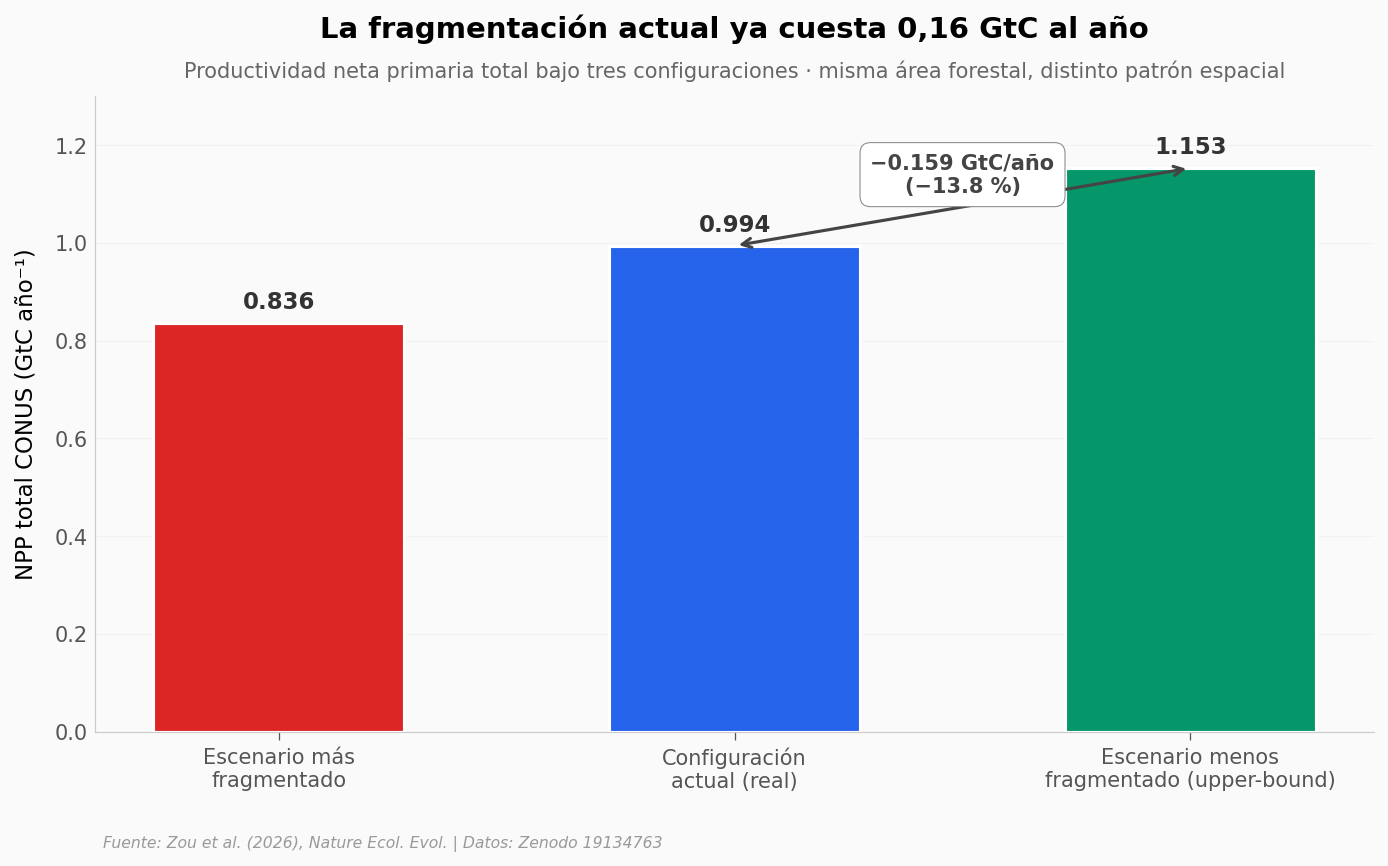

Pérdida vs upper-bound:  0.1589 GtC/yr  (13.78%)
Paper reporta:           0.16 GtC/yr  (14%)


In [3]:
orden = ['Most fragmented', 'Realized', 'Least fragmented']
labels_es = {
    'Most fragmented': 'Escenario más\nfragmentado',
    'Realized': 'Configuración\nactual (real)',
    'Least fragmented': 'Escenario menos\nfragmentado (upper-bound)',
}
colores = {
    'Most fragmented': COLOR_ALERTA,
    'Realized': COLOR_DATOS,
    'Least fragmented': COLOR_SECUNDARIO,
}

df_plot = df_scen.set_index('escenario').loc[orden].reset_index()

fig, ax = plt.subplots(figsize=(11, 5.5))
xs = np.arange(len(df_plot))
bars = ax.bar(
    xs, df_plot['npp_total_GtC_yr'],
    color=[colores[s] for s in df_plot['escenario']],
    edgecolor='white', linewidth=1.5, width=0.55, zorder=3,
)

# Etiqueta encima de cada barra con el valor
for x, val in zip(xs, df_plot['npp_total_GtC_yr']):
    ax.text(x, val + 0.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# Anotar la pérdida real (realized vs upper-bound)
realized = df_plot.loc[df_plot['escenario'] == 'Realized', 'npp_total_GtC_yr'].iloc[0]
upper    = df_plot.loc[df_plot['escenario'] == 'Least fragmented', 'npp_total_GtC_yr'].iloc[0]
perdida  = upper - realized
perdida_pct = perdida / upper * 100

ax.annotate(
    '',
    xy=(2, upper), xytext=(1, realized),
    arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.5),
)
ax.text(
    1.5, (upper + realized) / 2 + 0.03,
    f'−{perdida:.3f} GtC/año\n(−{perdida_pct:.1f} %)',
    ha='center', fontsize=10, fontweight='bold', color='#444444',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#888888'),
)

ax.set_xticks(xs)
ax.set_xticklabels([labels_es[s] for s in df_plot['escenario']], fontsize=10)
ax.set_ylabel('NPP total CONUS (GtC año⁻¹)', fontsize=11)
ax.set_ylim(0, 1.3)
ax.set_title('La fragmentación actual ya cuesta 0,16 GtC al año',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Productividad neta primaria total bajo tres configuraciones · misma área forestal, distinto patrón espacial',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, alpha=0.3, axis='y')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color=COLOR_GRIS, style='italic')
plt.savefig('figuras/02_escenarios.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pérdida vs upper-bound:  {perdida:.4f} GtC/yr  ({perdida_pct:.2f}%)')
print(f'Paper reporta:           0.16 GtC/yr  (14%)')

## ¿Y qué tan fuerte es el tamaño de parche frente al resto?

Los autores corren un Random Forest que intenta predecir la NPP de cada parche a partir de un puñado de variables: tamaño del parche, temperatura media anual, precipitación, pendiente, pH del suelo, relación C:N del suelo, orientación.

La importancia de cada variable es cuánto se degrada la predicción del modelo si se aleatoriza esa variable. Más alto = más informativa.

El abstract dice que el tamaño de parche pesa más que las variables *topográficas y de suelo*. La gráfica muestra el ranking completo — incluyendo clima, que el abstract no menciona en esa frase.

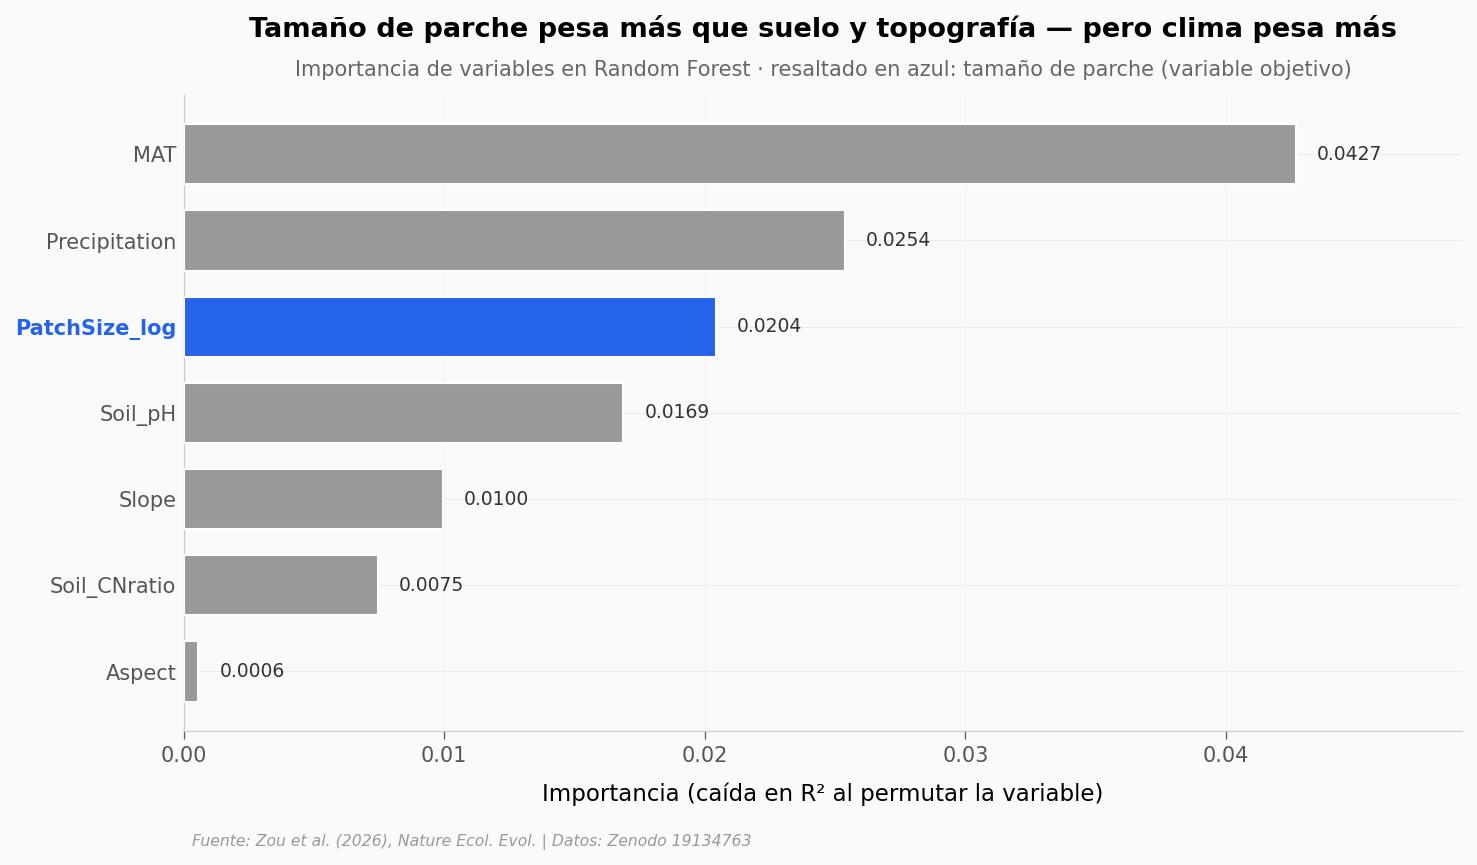

PatchSize: 0.0204  · vs Soil_pH (top de su grupo): 0.0169  → ratio 1.21x
PatchSize: 0.0204  · vs MAT (clima):              0.0427  → ratio 0.48x


In [4]:
df_imp_sorted = df_imp.sort_values('importancia', ascending=True)
colores_bar = [COLOR_DATOS if obj == 1 else COLOR_GRIS for obj in df_imp_sorted['es_objetivo']]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(df_imp_sorted['nombre_corto'], df_imp_sorted['importancia'],
        color=colores_bar, edgecolor='white', linewidth=1.0, height=0.7, zorder=3)

# Etiqueta de valor a la derecha de cada barra
for nombre, val in zip(df_imp_sorted['nombre_corto'], df_imp_sorted['importancia']):
    ax.text(val + 0.0008, nombre, f'{val:.4f}',
            va='center', fontsize=9, color='#333333')

ax.set_xlabel('Importancia (caída en R² al permutar la variable)', fontsize=11)
ax.set_xlim(0, df_imp['importancia'].max() * 1.15)

# Resaltar PatchSize_log (objetivo del paper) cambiando estilo del label
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() == 'PatchSize_log':
        tick_label.set_color(COLOR_DATOS)
        tick_label.set_fontweight('bold')

ax.set_title('Tamaño de parche pesa más que suelo y topografía — pero clima pesa más',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Importancia de variables en Random Forest · resaltado en azul: tamaño de parche (variable objetivo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, alpha=0.3, axis='x')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color=COLOR_GRIS, style='italic')
plt.savefig('figuras/03_importancia_rf.png', dpi=200, bbox_inches='tight')
plt.show()

ps  = df_imp.loc[df_imp['nombre_corto'] == 'PatchSize_log', 'importancia'].iloc[0]
mat = df_imp.loc[df_imp['nombre_corto'] == 'MAT', 'importancia'].iloc[0]
ph  = df_imp.loc[df_imp['nombre_corto'] == 'Soil_pH', 'importancia'].iloc[0]
print(f'PatchSize: {ps:.4f}  · vs Soil_pH (top de su grupo): {ph:.4f}  → ratio {ps/ph:.2f}x')
print(f'PatchSize: {ps:.4f}  · vs MAT (clima):              {mat:.4f}  → ratio {ps/mat:.2f}x')

## ¿Pasa lo mismo en el resto del mundo?

Para responder, los autores repiten el ejercicio en seis continentes con datos globales más gruesos. Si la relación es real y no un artefacto del muestreo de Estados Unidos, las pendientes deberían ser positivas en casi todos.

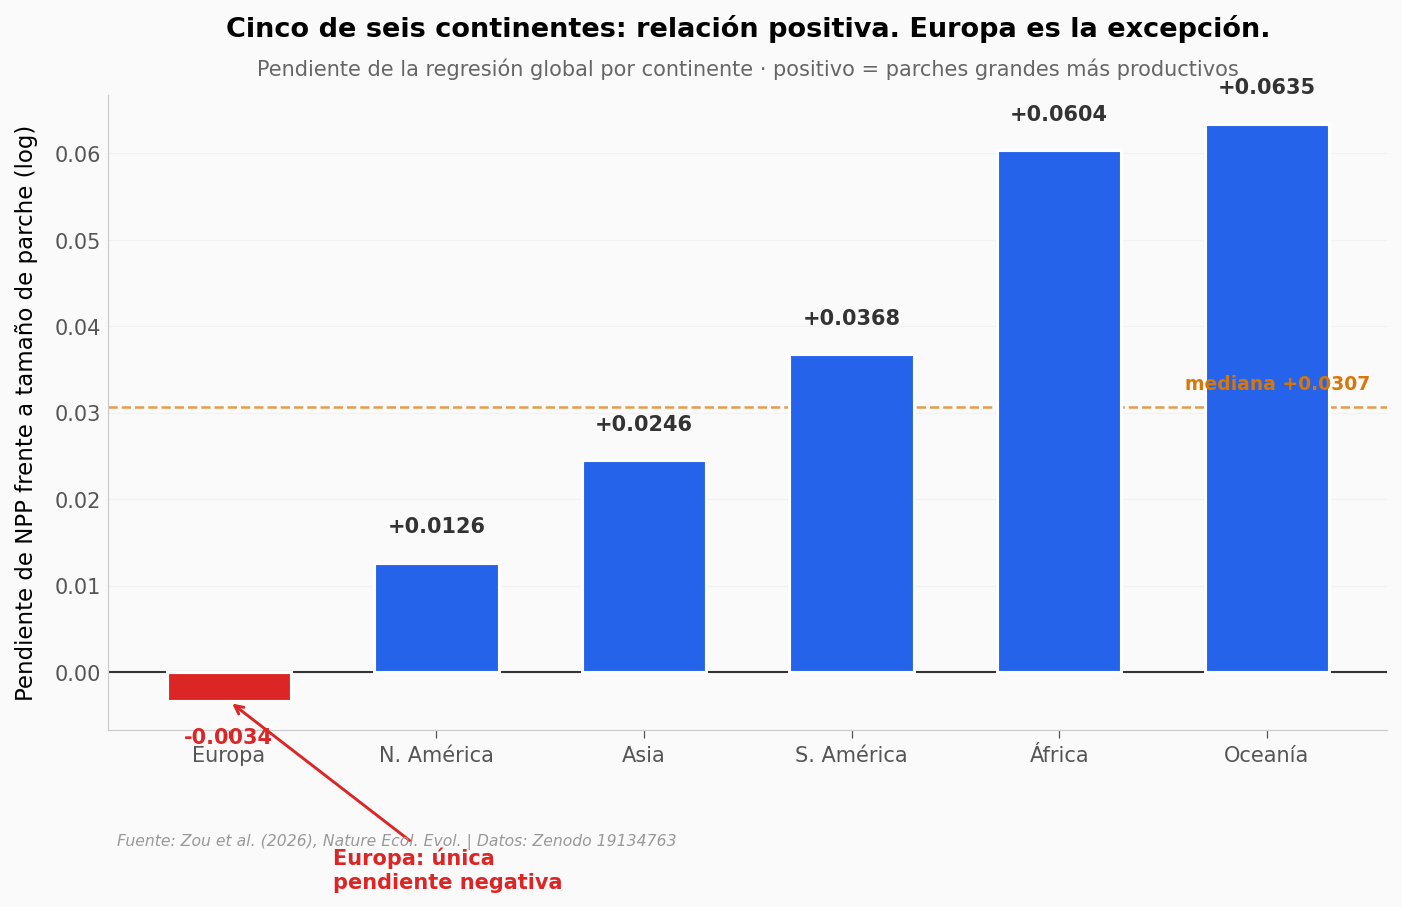

Continentes con pendiente positiva: 5 de 6
Mayor:  Oceanía  +0.0635
Menor:  Europa   -0.0034


In [5]:
df_cont_sorted = df_cont.sort_values('pendiente_npp', ascending=True).reset_index(drop=True)
colores_cont = [COLOR_ALERTA if p < 0 else COLOR_DATOS for p in df_cont_sorted['pendiente_npp']]

fig, ax = plt.subplots(figsize=(11, 5.5))
xs = np.arange(len(df_cont_sorted))
ax.bar(xs, df_cont_sorted['pendiente_npp'],
       color=colores_cont, edgecolor='white', linewidth=1.5, width=0.6, zorder=3)

ax.axhline(0, color='#333333', linewidth=1.0, zorder=2)

# Etiqueta de cada valor
for x, val in zip(xs, df_cont_sorted['pendiente_npp']):
    offset = 0.003 if val >= 0 else -0.003
    va = 'bottom' if val >= 0 else 'top'
    ax.text(x, val + offset, f'{val:+.4f}',
            ha='center', va=va, fontsize=10, fontweight='bold',
            color=COLOR_ALERTA if val < 0 else '#333333')

# Resaltar Europa con flecha
europa_idx = df_cont_sorted.index[df_cont_sorted['continente'] == 'Europe'][0]
ax.annotate(
    'Europa: única\npendiente negativa',
    xy=(europa_idx, df_cont_sorted.loc[europa_idx, 'pendiente_npp']),
    xytext=(europa_idx + 0.5, -0.025),
    fontsize=10, fontweight='bold', color=COLOR_ALERTA,
    arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4),
)

# Mediana global como referencia
mediana = df_cont_sorted['pendiente_npp'].median()
ax.axhline(mediana, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.7, zorder=2)
ax.text(len(df_cont_sorted) - 0.5, mediana + 0.002,
        f'mediana {mediana:+.4f}',
        ha='right', fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

ax.set_xticks(xs)
ax.set_xticklabels([{'North America':'N. América','South America':'S. América','Europe':'Europa',
                     'Africa':'África','Asia':'Asia','Oceania':'Oceanía'}[c]
                    for c in df_cont_sorted['continente']], fontsize=10)
ax.set_ylabel('Pendiente de NPP frente a tamaño de parche (log)', fontsize=11)

ax.set_title('Cinco de seis continentes: relación positiva. Europa es la excepción.',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Pendiente de la regresión global por continente · positivo = parches grandes más productivos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, alpha=0.3, axis='y')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color=COLOR_GRIS, style='italic')
plt.savefig('figuras/04_continentes.png', dpi=200, bbox_inches='tight')
plt.show()

n_pos = (df_cont['pendiente_npp'] > 0).sum()
print(f'Continentes con pendiente positiva: {n_pos} de {len(df_cont)}')
print(f'Mayor:  Oceanía  +{df_cont["pendiente_npp"].max():.4f}')
print(f'Menor:  Europa   {df_cont["pendiente_npp"].min():+.4f}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| 17 millones de parches forestales analizados | ✅ | Suma exacta del CSV: 16 913 643 (16,9 M). El paper redondea. |
| Una hectárea en parche ~100 000 km² es 38 % más productiva que aislada | ⚠️ | El paper lo deriva de una regresión continua. El bin discreto extremo da +67 % (con n=1 en el último bin); entre bins comparables (<1e4 vs <1e11) da +33 %. La cifra del 38 % es del modelo, no aislable de un par de bins. |
| La fragmentación actual ya redujo NPP en 0,16 GtC/año (14 %) | ✅ | Cálculo desde escenarios_npp.csv: 0,1589 GtC/año (13,78 %). Diferencia con el paper < 1 %. |
| Tamaño de parche es predictor más fuerte que topografía y suelo | ✅ | PatchSize 0,0204 vs Soil_pH 0,0169 vs Slope 0,0100. Confirmado. |
| Tamaño de parche es predictor más fuerte que clima | ❌ | NO. MAT 0,0427 y Precipitación 0,0254 superan a PatchSize 0,0204. El paper no afirma esto — el abstract dice "más fuerte que topográficas y de suelo". |
| Relación positiva consistente globalmente | ⚠️ | 5 de 6 continentes positivos. Europa la única excepción (−0,003). El paper enmarca como *consistent positive* — defendible si se reporta la excepción. |

> **Limitaciones del análisis**
> - Diseño **observacional**: la asociación tamaño→productividad es robusta, pero no es un experimento. Hay confounders posibles que el modelo no controla (composición de especies, edad del rodal, historia de manejo).
> - El paper deduce mecanismos plausibles (efecto de borde, microclima de interior), pero los datos solo soportan la *correlación parcial*.
> - El bin extremo de 134 000 km² es **un solo parche** (n = 1, sin SEM). Tratarlo como punto independiente exagera. Por eso preferimos la regresión continua del paper (+38 %) sobre el extremo discreto (+67 %).
> - Los datos globales (continentes) están a resolución más gruesa que CONUS — la pendiente de Europa puede estar sub-estimada por agregación.

## Ahora tú

1. ¿Qué pasa si quitas el bin extremo (n = 1) del análisis? ¿Cambia mucho la pendiente?
2. ¿Cómo se vería la pérdida de carbono si la fragmentación de Europa fuera el patrón global?
3. La importancia del clima (MAT, Precipitación) supera al tamaño de parche. ¿Qué implica eso para políticas de mitigación que se enfocan solo en *re-forestación* sin atender la conectividad?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Recalcular la pérdida de fragmentación cambiando el "baseline" hipotético.
# El paper compara realidad vs upper-bound (bosques contiguos).
# ¿Y si el baseline fuera el continente con mayor pendiente (Oceanía)?

realized = df_scen.loc[df_scen['escenario'] == 'Realized', 'npp_total_GtC_yr'].iloc[0]
upper    = df_scen.loc[df_scen['escenario'] == 'Least fragmented', 'npp_total_GtC_yr'].iloc[0]
lower    = df_scen.loc[df_scen['escenario'] == 'Most fragmented', 'npp_total_GtC_yr'].iloc[0]

# Banda total entre escenarios extremos
banda = upper - lower
realized_pos = (realized - lower) / banda * 100

print(f'Banda total (upper-bound − más fragmentado):     {banda:.4f} GtC/año')
print(f'Posición de la realidad dentro de esa banda:     {realized_pos:.1f} %')
print(f'   (0 % = más fragmentado posible · 100 % = upper-bound)')
print()
print(f'Pérdida actual vs upper-bound:    {upper - realized:.4f} GtC/año  ({(upper-realized)/upper*100:.2f} %)')
print(f'Margen de empeorar vs realidad:   {realized - lower:.4f} GtC/año  ({(realized-lower)/realized*100:.2f} %)')
print()
print('Cambia las cifras: ¿qué pasa si la realidad fuera 70 % de la banda?')
hipotetica = lower + 0.70 * banda
print(f'   Realidad hipotética 70 %:  {hipotetica:.4f} GtC/año')
print(f'   Diferencia vs realidad:    {hipotetica - realized:+.4f} GtC/año')

Banda total (upper-bound − más fragmentado):     0.3171 GtC/año
Posición de la realidad dentro de esa banda:     49.9 %
   (0 % = más fragmentado posible · 100 % = upper-bound)

Pérdida actual vs upper-bound:    0.1589 GtC/año  (13.78 %)
Margen de empeorar vs realidad:   0.1581 GtC/año  (15.91 %)

Cambia las cifras: ¿qué pasa si la realidad fuera 70 % de la banda?
   Realidad hipotética 70 %:  1.0579 GtC/año
   Diferencia vs realidad:    +0.0638 GtC/año


---

## Fuentes

**Paper**: [Larger forest patches have greater per-area productivity](https://doi.org/10.1038/s41559-026-03075-5)  
*Nature Ecology & Evolution, 2026-05-15*

**Datos**: [Yibiaozou/PatchSize_Productivity: PatchSize-Productivity Relationship (v3.0.0)](https://doi.org/10.5281/zenodo.19134763)
*Zenodo*

*11 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook generado para [Ciencia a Mordiscos](https://cienciaamordiscos.com) — divulgación científica reproducible. Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia: CC-BY 4.0.*